# MNIST


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

ROOT = Path.cwd().resolve()
if not (ROOT / "data" / "mnist.npz").exists():
    ROOT = Path("..").resolve()
DATA_PATH = ROOT / "data" / "mnist.npz"

with np.load(DATA_PATH, allow_pickle=False) as data:
    x_train = data["x_train"]
    y_train = data["y_train"]
    x_test = data["x_test"]
    y_test = data["y_test"]

print(DATA_PATH)
print("train images", x_train.shape, x_train.dtype)
print("train labels", y_train.shape, y_train.dtype)
print("test images ", x_test.shape, x_test.dtype)
print("test labels ", y_test.shape, y_test.dtype)

/Users/mausamgurung/Projects/autoencoder-implementation/data/mnist.npz
train images (60000, 28, 28) uint8
train labels (60000,) uint8
test images  (10000, 28, 28) uint8
test labels  (10000,) uint8


## Shapes and pixel values


In [2]:
pixels = 28 * 28
print(f"pixels per image: {pixels}")
print(f"train pixel range: {int(x_train.min())} to {int(x_train.max())}")
print(f"test pixel range:  {int(x_test.min())} to {int(x_test.max())}")
print(f"distinct pixel values in training: {np.unique(x_train).size}")
print(f"training images on disk: {x_train.nbytes / 1e6:.1f} MB")
print(f"test images on disk:     {x_test.nbytes / 1e6:.1f} MB")
print(f"labels: {np.unique(y_train).tolist()}")

pixels per image: 784
train pixel range: 0 to 255
test pixel range:  0 to 255
distinct pixel values in training: 256
training images on disk: 47.0 MB
test images on disk:     7.8 MB
labels: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


## Class counts


digit    train  train %     test   test %
    0     5923    9.87%      980    9.80%
    1     6742   11.24%     1135   11.35%
    2     5958    9.93%     1032   10.32%
    3     6131   10.22%     1010   10.10%
    4     5842    9.74%      982    9.82%
    5     5421    9.04%      892    8.92%
    6     5918    9.86%      958    9.58%
    7     6265   10.44%     1028   10.28%
    8     5851    9.75%      974    9.74%
    9     5949    9.91%     1009   10.09%


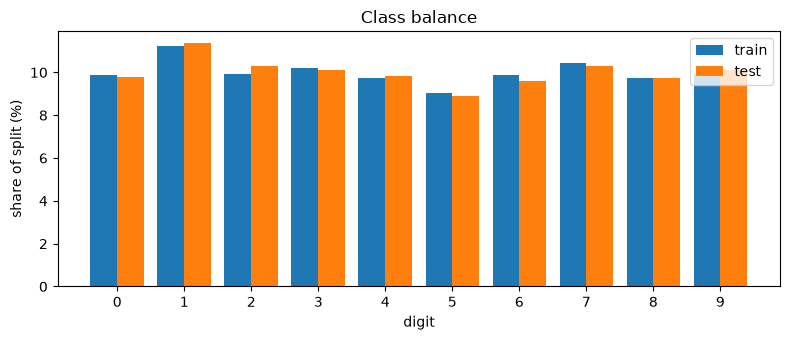

In [3]:
digits = np.arange(10)
train_counts = np.bincount(y_train, minlength=10)
test_counts = np.bincount(y_test, minlength=10)

print(f"{'digit':>5} {'train':>8} {'train %':>8} {'test':>8} {'test %':>8}")
for digit in digits:
    print(
        f"{digit:5d} {train_counts[digit]:8d} {100 * train_counts[digit] / len(y_train):7.2f}%"
        f" {test_counts[digit]:8d} {100 * test_counts[digit] / len(y_test):7.2f}%"
    )

fig, ax = plt.subplots(figsize=(8, 3.5))
width = 0.4
ax.bar(digits - width / 2, 100 * train_counts / len(y_train), width, label="train")
ax.bar(digits + width / 2, 100 * test_counts / len(y_test), width, label="test")
ax.set_xticks(digits)
ax.set_xlabel("digit")
ax.set_ylabel("share of split (%)")
ax.set_title("Class balance")
ax.legend()
fig.tight_layout()
plt.show()

## Examples


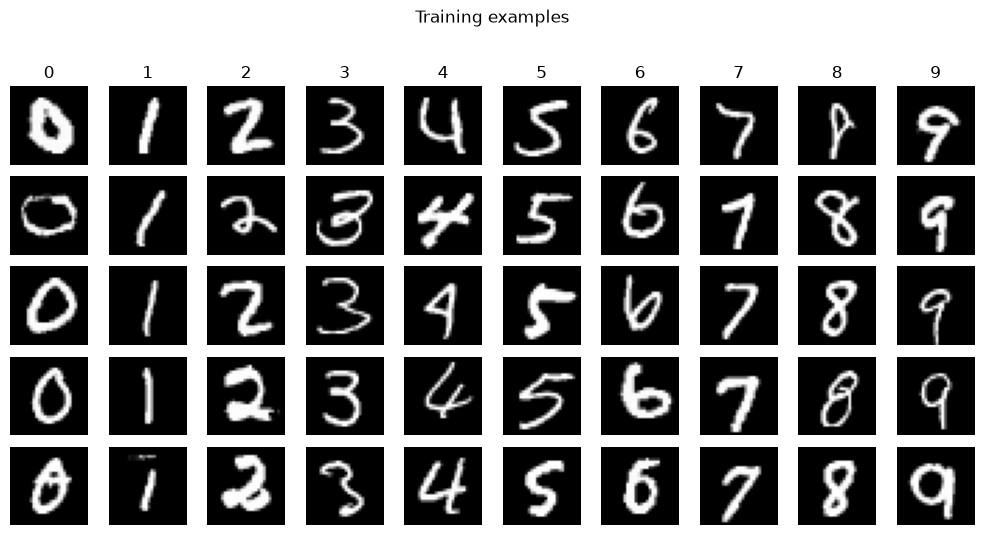

In [4]:
rng = np.random.default_rng(0)
rows = 5
fig, axes = plt.subplots(rows, 10, figsize=(10, 5.2))
for digit in digits:
    picks = rng.choice(np.flatnonzero(y_train == digit), size=rows, replace=False)
    for row, index in enumerate(picks):
        axes[row, digit].imshow(x_train[index], cmap="gray")
        axes[row, digit].axis("off")
        if row == 0:
            axes[row, digit].set_title(str(digit))
fig.suptitle("Training examples", y=1.02)
fig.tight_layout()
plt.show()

## Ink vs background


blank pixels, train: 80.9%
blank pixels, test:  80.7%
ink pixels per training image: mean 150, median 150, of 784

digit  mean ink pixels  blank %
    0            192.0    75.5%
    1             85.8    89.1%
    2            168.8    78.5%
    3            163.3    79.2%
    4            141.8    81.9%
    5            152.3    80.6%
    6            156.9    80.0%
    7            131.4    83.2%
    8            173.3    77.9%
    9            143.0    81.8%


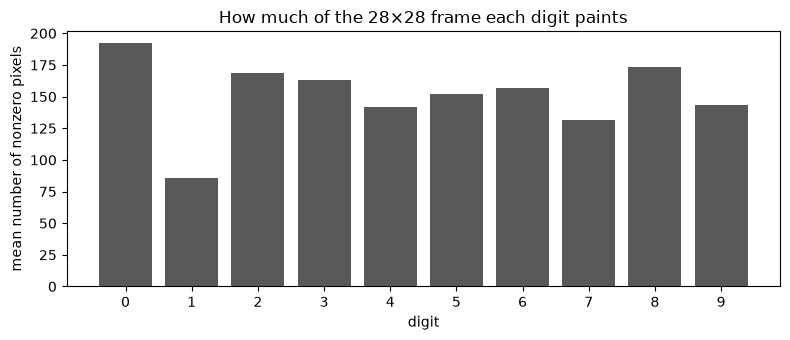

In [5]:
train_blank = (x_train == 0).mean()
test_blank = (x_test == 0).mean()
ink_per_image = (x_train > 0).sum(axis=(1, 2))

print(f"blank pixels, train: {100 * train_blank:.1f}%")
print(f"blank pixels, test:  {100 * test_blank:.1f}%")
print(f"ink pixels per training image: mean {ink_per_image.mean():.0f}, median {np.median(ink_per_image):.0f}, of {pixels}")

ink_by_digit = [(x_train[y_train == digit] > 0).sum(axis=(1, 2)).mean() for digit in digits]
blank_by_digit = [(x_train[y_train == digit] == 0).mean() for digit in digits]

print()
print(f"{'digit':>5} {'mean ink pixels':>16} {'blank %':>8}")
for digit, ink, blank in zip(digits, ink_by_digit, blank_by_digit):
    print(f"{digit:5d} {ink:16.1f} {100 * blank:7.1f}%")

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.bar(digits, ink_by_digit, color="0.35")
ax.set_xticks(digits)
ax.set_xlabel("digit")
ax.set_ylabel("mean number of nonzero pixels")
ax.set_title("How much of the 28×28 frame each digit paints")
fig.tight_layout()
plt.show()

## Where the ink sits


Share of images with ink, by row (top to bottom):
[0.    0.    0.007 0.025 0.086 0.171 0.24  0.293 0.305 0.294 0.278 0.271
 0.276 0.29  0.302 0.303 0.291 0.275 0.267 0.272 0.279 0.273 0.236 0.177
 0.092 0.034 0.013 0.001]
Share of images with ink, by column (left to right):
[0.    0.    0.001 0.006 0.022 0.057 0.106 0.168 0.233 0.293 0.34  0.371
 0.396 0.419 0.434 0.445 0.439 0.411 0.363 0.296 0.221 0.152 0.096 0.053
 0.024 0.007 0.001 0.   ]


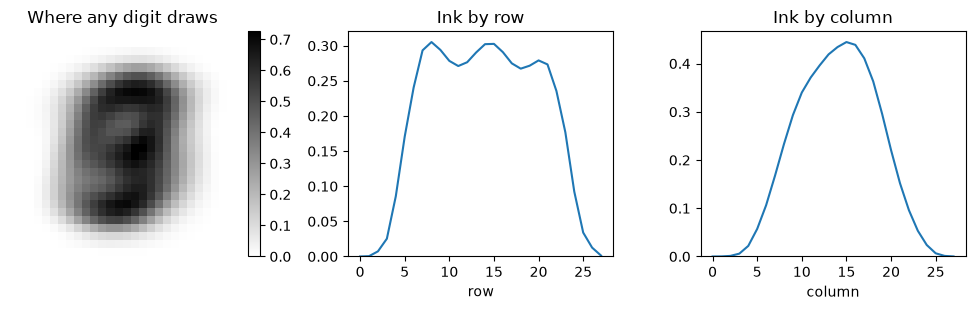

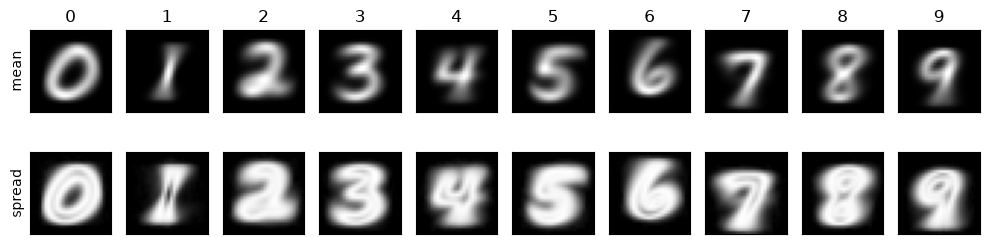

In [6]:
occupied = (x_train > 0).mean(axis=0)
row_use = occupied.mean(axis=1)
col_use = occupied.mean(axis=0)

print("Share of images with ink, by row (top to bottom):")
print(np.array2string(row_use, precision=3, suppress_small=True))
print("Share of images with ink, by column (left to right):")
print(np.array2string(col_use, precision=3, suppress_small=True))

fig, axes = plt.subplots(1, 3, figsize=(10, 3.2))
image = axes[0].imshow(occupied, cmap="gray_r")
axes[0].set_title("Where any digit draws")
axes[0].axis("off")
fig.colorbar(image, ax=axes[0], fraction=0.046)
axes[1].plot(row_use)
axes[1].set_title("Ink by row")
axes[1].set_xlabel("row")
axes[1].set_ylim(0, None)
axes[2].plot(col_use)
axes[2].set_title("Ink by column")
axes[2].set_xlabel("column")
axes[2].set_ylim(0, None)
fig.tight_layout()
plt.show()

means = np.stack([x_train[y_train == digit].mean(axis=0) for digit in digits])
stds = np.stack([x_train[y_train == digit].std(axis=0) for digit in digits])

fig, axes = plt.subplots(2, 10, figsize=(10, 3.0))
for digit in digits:
    axes[0, digit].imshow(means[digit], cmap="gray")
    axes[1, digit].imshow(stds[digit], cmap="gray")
    for ax in (axes[0, digit], axes[1, digit]):
        ax.set_xticks([])
        ax.set_yticks([])
    axes[0, digit].set_title(str(digit))
axes[0, 0].set_ylabel("mean")
axes[1, 0].set_ylabel("spread")
fig.tight_layout()
plt.show()